In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,  mean_absolute_error
%matplotlib inline

In [3]:
from sklearn.datasets import fetch_california_housing

In [5]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
df.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


<Axes: >

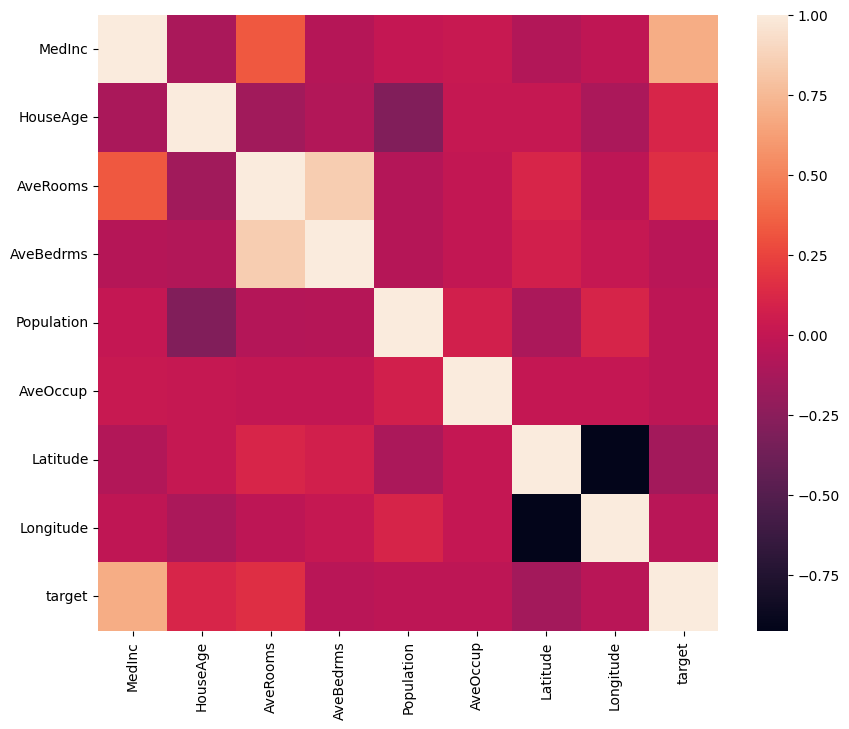

In [13]:
plt.figure(figsize=(10, 8))

sns.heatmap(df.corr())

In [14]:
# averoms and avebedroms correlation 1 so we remove one

In [17]:
df = df.drop(columns=['AveBedrms'])

In [18]:
df.head(2)

,MedInc,HouseAge,AveRooms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,2401.0,2.109842,37.86,-122.22,3.585


Text(0.5, 1.0, 'house age vs price')

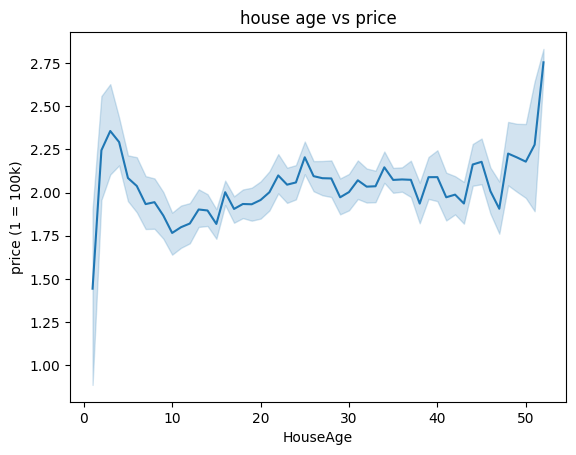

In [27]:
sns.lineplot(data=df, x='HouseAge', y='target')
plt.ylabel('price (1 = 100k)')
plt.title('house age vs price')

# Linear Regression

In [28]:
X = df.drop(columns=['target'])
y = df['target']

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [32]:
# scaling data

In [33]:
scaler = StandardScaler()

In [34]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
model_lr = LinearRegression()

In [36]:
model_lr.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
y_pred_lr = model_lr.predict(X_test_scaled)

In [39]:
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

In [89]:
def evaluate_regression(y_test, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"\n=== {model_name} ===")
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae}

In [90]:
evaluate_regression(y_test, y_pred_lr, "Linear Regression")


=== Linear Regression ===


{'R2': 0.5960246019349678,
 'RMSE': np.float64(0.7337126883273913),
 'MAE': 0.5408676281299724}

In [42]:
# The model explains 59% of the variance in house prices.

In [43]:
# lasso and ridge

In [46]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.linear_model import Ridge, Lasso

In [55]:
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10, 100])
ridge_cv.fit(X_train_scaled, y_train)
print(f"Best alpha Ridge {ridge_cv.alpha_}")

Best alpha Ridge 0.01


In [61]:
lasso_cv = LassoCV(alphas=[0.01, 0.1, 1.0, 10, 100])
lasso_cv.fit(X_train_scaled, y_train)
print(f"Best alpha lasso {lasso_cv.alpha_}")

Best alpha lasso 0.01


In [70]:
ridge = Ridge(alpha=0.01)
ridge.fit(X_train_scaled,y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge R²: {r2_ridge:.4f}")

Ridge R²: 0.5960


In [71]:
lasso= Lasso(alpha=0.01)
lasso.fit(X_train_scaled,y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
r2_lasso = r2_score(y_test, y_pred_ridge)
print(f"Lasso R²: {r2_lasso:.4f}")

Lasso R²: 0.5960


# decision tree

In [75]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [78]:
for depth in [3,5,7,10,19,25]:
    dtr = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dtr.fit(X_train_scaled,y_train)
    y_pred_dtr = dtr.predict(X_test_scaled)
    r2_dtr = r2_score(y_test, y_pred_dtr)
    print(f"max_depth={depth}: R²={r2_dtr:.4f}")

max_depth=3: R²=0.5075
max_depth=5: R²=0.5983
max_depth=7: R²=0.6447
max_depth=10: R²=0.6691
max_depth=19: R²=0.6056
max_depth=25: R²=0.5906


In [93]:
model_dtr = DecisionTreeRegressor(max_depth=10, random_state=42)
model_dtr.fit(X_train_scaled, y_train)
y_pred_dtr = model_dtr.predict(X_test_scaled)

evaluate_regression(y_test, y_pred_dtr, "Decision Tree Regressor")


=== Decision Tree Regressor ===


{'R2': 0.6691488357858911,
 'RMSE': np.float64(0.6639951456814049),
 'MAE': 0.4435037274388035}

# Random forest

In [94]:
for n in [50, 100, 200, 300, 500]:
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X_train_scaled, y_train)
    y_pred_rf = rf.predict(X_test_scaled)
    r2_rf = r2_score(y_test, y_pred_rf)
    print(f"n_estimators={n}: R2={r2_rf:.3f}")

n_estimators=50: R2=0.805
n_estimators=100: R2=0.806
n_estimators=200: R2=0.807
n_estimators=300: R2=0.808
n_estimators=500: R2=0.808


In [95]:
# nestimator = 100 is optimal balance

In [97]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled,y_train)
y_pred_rf = rf.predict(X_test_scaled)
evaluate_regression(y_test, y_pred_rf, "Random Forest")


=== Random Forest ===


{'R2': 0.80635217038733,
 'RMSE': np.float64(0.5079896778256372),
 'MAE': 0.3329389779800354}

# XGB Regressor

In [99]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor


In [106]:
param_grid = {
    'n_estimators': [100,200,300,400],
    'max_depth': [3, 4, 5, 6,10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}
xgb = XGBRegressor(random_state=42)
grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f" best params = {grid_search.best_params_}")
print(f" best score = {grid_search.best_score_}")

 best params = {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400}
 best score = 0.8388444899110044


In [109]:
model_xgb = XGBRegressor(n_estimators=400,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss')


In [110]:
model_xgb.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets i

In [113]:
y_pred_xgb = model_xgb.predict(X_test_scaled)

In [114]:
evaluate_regression(y_test, y_pred_xgb, "XGB Regresson")


=== XGB Regresson ===


{'R2': 0.8480419315496219,
 'RMSE': np.float64(0.44999786474377246),
 'MAE': 0.2936009208922503}

In [118]:
results = {}

results['Linear Regression'] = evaluate_regression(y_test, y_pred_lr, "Linear Regression")
results['Ridge'] = evaluate_regression(y_test, y_pred_ridge, "Ridge")
results['Lasso'] = evaluate_regression(y_test, y_pred_lasso, "Lasso")
results['Decision Tree'] = evaluate_regression(y_test, y_pred_dtr, "Decision Tree")
results['Random Forest'] = evaluate_regression(y_test, y_pred_rf, "Random Forest")
results['XGBoost'] = evaluate_regression(y_test, y_pred_xgb, "XGBoost")

print("\n=== FINAL MODEL COMPARISON ===")
print(f"{'Model':<20} {'R²':>8} {'RMSE':>8} {'MAE':>8}")
print("-" * 46)
for model_name, metrics in results.items():
    print(f"{model_name:<20} {metrics['R2']:>8.4f} {metrics['RMSE']:>8.4f} {metrics['MAE']:>8.4f}")


=== Linear Regression ===

=== Ridge ===

=== Lasso ===

=== Decision Tree ===

=== Random Forest ===

=== XGBoost ===

=== FINAL MODEL COMPARISON ===
Model                      R²     RMSE      MAE
----------------------------------------------
Linear Regression      0.5960   0.7337   0.5409
Ridge                  0.5960   0.7337   0.5409
Lasso                  0.5934   0.7361   0.5418
Decision Tree          0.6691   0.6640   0.4435
Random Forest          0.8064   0.5080   0.3329
XGBoost                0.8480   0.4500   0.2936
